<a href="https://colab.research.google.com/github/casper3790/High-School-Psychology-Tree-Hole/blob/main/%E4%B8%BB%E9%A1%8C%E4%B8%80_%E5%BE%9E%E6%83%A1%E6%84%8F%E7%B6%B2%E5%9D%80%E5%81%B5%E6%B8%AC%E5%88%B0%E5%B0%8D%E6%8A%97%E5%BC%8F%E6%94%BB%E6%93%8A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛡️ AI 安全攻防實戰：從惡意網址偵測到對抗式攻擊
**AI Security Workshop: Malicious URL Detection & FGSM Attack**

### 課程目標
1.  **資料工程**：處理不平衡資料集，將網址轉換為模型可讀的向量。
2.  **模型訓練**：建立深度神經網路 (Deep Neural Network) 來識別惡意網址。
3.  **對抗攻擊**：實作 **FGSM (Fast Gradient Sign Method)**，欺騙訓練好的模型。

### 核心技術
* **TensorFlow/Keras**: 深度學習框架
* **Tokenizer & Embedding**: 自然語言處理 (NLP)
* **Gradient Tape**: 計算梯度以生成對抗擾動

In [ ]:
# @title 0. 安裝必要套件 (Install Dependencies)

# 使用 pip 安裝必要套件
# -q 代表安靜模式 (Quiet mode)，減少輸出訊息
!pip install -q numpy pandas matplotlib seaborn scikit-learn tensorflow kagglehub

print("套件安裝完成！")

套件安裝完成！


In [ ]:
# @title 1. 環境建置與套件載入 (Setup)
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 設定隨機種子 (Random Seed) 以確保所有人結果一致
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"環境建置完成！TensorFlow Version: {tf.__version__}")

環境建置完成！TensorFlow Version: 2.19.0


### 📊 資料載入與前處理 (Data Preparation)

現實生活中的資安數據通常是**極度不平衡 (Imbalanced)** 的。良性網址 (Benign) 的數量遠遠多於惡意網址 (Phishing/Malware)。

**為什麼這很危險？**
如果 95% 的網址都是良性的，模型只要學會「全部猜良性」，就能得到 95% 的準確率，但它完全沒有偵測能力。

**解決方案：** 我們將使用 **降採樣 (Downsampling)** 技術，將良性樣本的數量刪減至與惡意樣本相同，強迫模型學習真正的特徵。

In [ ]:
# @title 2. 載入資料集並處理不平衡 (Data Balancing)
import kagglehub
import os

print("正在從 Kaggle 下載資料集...")

# 1. 使用 kagglehub 下載資料集
# 下載後會回傳檔案儲存的資料夾路徑
path = kagglehub.dataset_download("sid321axn/malicious-urls-dataset")

print("資料集下載路徑:", path)

# 2. 讀取 CSV 檔案
# 通常這個資料集內的檔案名稱是 'malicious_phish.csv'
csv_path = os.path.join(path, 'malicious_phish.csv')
df = pd.read_csv(csv_path)

# 3. 標籤編碼：將 Benign 設為 0，其他攻擊類型 (phishing, defacement, malware) 設為 1
df['label'] = df['type'].apply(lambda x: 0 if x == 'benign' else 1)

# 4. 檢視原始分佈
print(f"--- 原始資料分佈 ---\n{df['label'].value_counts()}")

# 5. 執行降採樣 (Downsampling)
# 分離良性與惡意樣本
benign_df = df[df['label'] == 0]
malicious_df = df[df['label'] == 1]

# 隨機抽取跟惡意樣本一樣多的良性樣本
benign_downsampled = benign_df.sample(n=len(malicious_df), random_state=42)

# 合併並打亂順序
df_balanced = pd.concat([benign_downsampled, malicious_df]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n--- 平衡後資料分佈 ---\n{df_balanced['label'].value_counts()}")


正在從 Kaggle 下載資料集...
Using Colab cache for faster access to the 'malicious-urls-dataset' dataset.
資料集下載路徑: /kaggle/input/malicious-urls-dataset
--- 原始資料分佈 ---
label
0    428103
1    223088
Name: count, dtype: int64

--- 平衡後資料分佈 ---
label
0    223088
1    223088
Name: count, dtype: int64


### 🔢 特徵工程：讓電腦讀懂網址

電腦看不懂文字，只能看懂數字。我們需要進行兩個步驟：

1.  **Tokenization (分詞/標記化)**：
    我們使用 **`char_level=True`** (字元層級) 的方式。為什麼？因為駭客喜歡用混淆字元 (例如用 `0` 取代 `o`，`g00gle.com`)。字元層級的模型比單字層級更能抓到這種微小的異常。

2.  **Padding (填充)**：
    神經網路需要固定長度的輸入。太短的網址補 0，太長的網址截斷。

In [ ]:
# @title 3. 文字轉向量 (Tokenization & Padding)

# --- 參數設定 ---
vocab_size = 5000   # 字典大小 (只取最常出現的前 5000 個字元/符號)
embedding_dim = 16  # 嵌入層維度 (每個字元轉成 16 維向量)
max_length = 100    # 最大長度 (只看網址前 100 個字)
oov_tok = "<OOV>"   # 未知字元用 out of vocabulary,OOV 標記

# 1. 建立 Tokenizer
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok, char_level=True)
tokenizer.fit_on_texts(df_balanced['url'])

# 2. 轉換為數字序列
sequences = tokenizer.texts_to_sequences(df_balanced['url'])

# 3. Padding (補零)
padded = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')

# 4. 切分訓練集與測試集 (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(padded, df_balanced['label'].values, test_size=0.2, random_state=SEED)

print(f"原始 URL 範例: {df_balanced['url'][0]}")
print(f"轉換後序列: {sequences[0]}")
print(f"Padding 後: {padded[0]}")
print(f"訓練集形狀: {X_train.shape}, 測試集形狀: {X_test.shape}")

原始 URL 範例: asamcgill.com/
轉換後序列: [5, 10, 5, 13, 9, 22, 6, 15, 15, 12, 9, 4, 13, 7]
Padding 後: [ 5 10  5 13  9 22  6 15 15 12  9  4 13  7  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0]
訓練集形狀: (356940, 100), 測試集形狀: (89236, 100)


### 🧠 建立與訓練深度學習模型

我們使用一個輕量級的神經網路架構：

1.  **Embedding Layer**: 將整數索引轉換為密集的語義向量。
2.  **GlobalAveragePooling1D**: 將整條網址的特徵平均化，提取全局特徵。
3.  **Dense (ReLU)**: 隱藏層，負責學習非線性關係。
4.  **Dense (Sigmoid)**: 輸出層，輸出 0~1 之間的機率值 (越接近 1 代表越惡意)。

🚀 開始訓練模型...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


11155/11155 ━━━━━━━━━━━━━━━━━━━━ 27s 2ms/step - accuracy: 0.8610 - loss: 0.3203 - val_accuracy: 0.8577 - val_loss: 0.3096
Epoch 2/5
11155/11155 ━━━━━━━━━━━━━━━━━━━━ 25s 2ms/step - accuracy: 0.9041 - loss: 0.2417 - val_accuracy: 0.9120 - val_loss: 0.2242
Epoch 3/5
11155/11155 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - accuracy: 0.9276 - loss: 0.1956 - val_accuracy: 0.9280 - val_loss: 0.1932
Epoch 4/5
11155/11155 ━━━━━━━━━━━━━━━━━━━━ 25s 2ms/step - accuracy: 0.9323 - loss: 0.1829 - val_accuracy: 0.9323 - val_loss: 0.1799
Epoch 5/5
11155/11155 ━━━━━━━━━━━━━━━━━━━━ 27s 2ms/step - accuracy: 0.9347 - loss: 0.1759 - val_accuracy: 0.9346 - val_loss: 0.1749


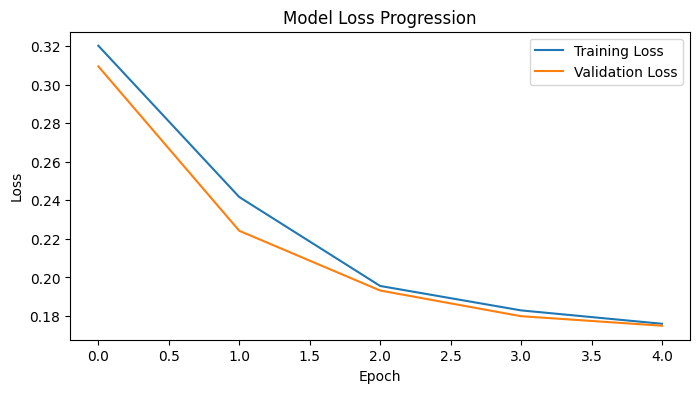

In [ ]:
# @title 4. 模型編譯與訓練 (Model Training)

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, embedding_dim, input_length=max_length, name='embedding_layer'),
    tf.keras.layers.GlobalAveragePooling1D(),
    # tf.keras.layers.LSTM(64, return_sequences=False),
    tf.keras.layers.Dense(24, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid', name='output_layer')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

print("🚀 開始訓練模型...")
history = model.fit(X_train, y_train,
                    epochs=5,
                    validation_data=(X_test, y_test),
                    batch_size=32,
                    verbose=1)

# 繪製 Loss 曲線
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Progression')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

### 📉 模型評估 (Evaluation)

我們利用 **混淆矩陣 (Confusion Matrix)** 來檢視模型表現。
* 左上 (TP): 預測良性，實際良性 (準確)
* 右下 (TN): 預測惡意，實際惡意 (準確)
* **右上 (FP): 誤判良性為惡意 (誤報)**
* **左下 (FN): 誤判惡意為良性 (漏報) -> 這是資安最擔心的！**

2789/2789 ━━━━━━━━━━━━━━━━━━━━ 3s 996us/step


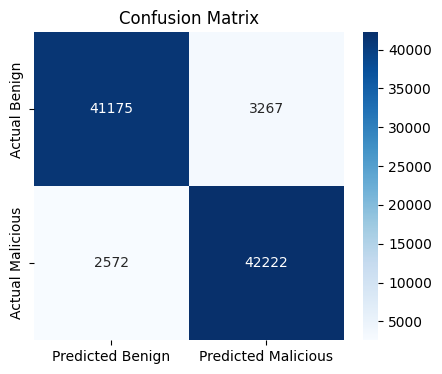

              precision    recall  f1-score   support

      Benign       0.94      0.93      0.93     44442
   Malicious       0.93      0.94      0.94     44794

    accuracy                           0.93     89236
   macro avg       0.93      0.93      0.93     89236
weighted avg       0.93      0.93      0.93     89236



In [ ]:
# @title 5. 檢視模型成效 (Confusion Matrix)

# 進行預測
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# 用預測結果和真實標籤計算混淆矩陣
# 繪製熱力圖
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Benign', 'Predicted Malicious'],
            yticklabels=['Actual Benign', 'Actual Malicious'])
plt.title('Confusion Matrix')
plt.show()

# 顯示詳細數據
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malicious']))

### ⚔️ 對抗式攻擊實作：FGSM (Fast Gradient Sign Method)

現在我们要扮演攻擊者 (Attacker)。

**FGSM 的核心概念：**
一般的訓練是計算梯度來「降低 Loss」；攻擊則是利用梯度(sign)來「增加 Loss」。我們只要找出讓模型誤差變大的方向，並在輸入資料加上一點點微小的擾動 (Perturbation, ϵ)，就能欺騙模型。

**公式：**
$$Adv\_Image = Image + \epsilon \times sign(\nabla_{Image}J(\theta, Image, Label))$$

*注意：因為文字是離散數據，我們這裡演示的是針對 Embedding 向量層 (Feature Space) 的白箱攻擊，證明模型的決策邊界是脆弱的。*

In [ ]:
# @title 6. 定義 FGSM 攻擊工具

# 1. 拆解模型：建立一個 "從 Embedding 輸入 -> 到最終預測輸出" 的子模型
# 我們需要略過 layer[0] (原本的 Embedding 層)，直接從 layer[1] 開始串接
# 因為文字不能直接微調（是離散的），所以我們在向量空間做攻擊
input_emb = tf.keras.Input(shape=(max_length, embedding_dim))

x = input_emb
# 使用迴圈自動讀取所有層
for layer in model.layers[1:]:
    x = layer(x)

output = x
classifier_model = tf.keras.Model(inputs=input_emb, outputs=output) # 模型的輸入輸出

loss_object = tf.keras.losses.BinaryCrossentropy() # 定義 Loss：用來衡量模型預測錯多少

def create_adversarial_pattern(input_seq, input_label):
    # 先把原始輸入轉成 embedding（模型內部的表示）
    embeddings = model.layers[0](input_seq)

    with tf.GradientTape() as tape:
        tape.watch(embeddings) # 追蹤 Embedding 的變化
        prediction = classifier_model(embeddings) # 用 Embedding 當輸入，做預測
        loss = loss_object(input_label, prediction) # 計算 loss

    # 計算梯度 (Gradient)：Loss 對 Embedding 的變化率
    gradient = tape.gradient(loss, embeddings)

    # 取梯度的方向 (Sign)
    signed_grad = tf.sign(gradient)
    return embeddings, signed_grad

print(f"✅ FGSM 攻擊工具建立完成！")


✅ FGSM 攻擊工具建立完成！


### 🎯 發動攻擊與結果觀察

我們將隨機挑選一個**模型原本預測正確的惡意網址**，並嘗試對其 Embedding 加上擾動，看能不能騙過模型，讓它以為這是良性網址。

* **Epsilon ($\epsilon$)**：代表擾動的強度。數值越大，攻擊越容易成功，但資料失真也越嚴重。
* 控制**攻擊效果**和**資料改變程度**之間的平衡

--- 攻擊參數 Epsilon: 0.1 ---
原始樣本預測 (惡意機率): 0.9382
對抗樣本預測 (惡意機率): 0.0107


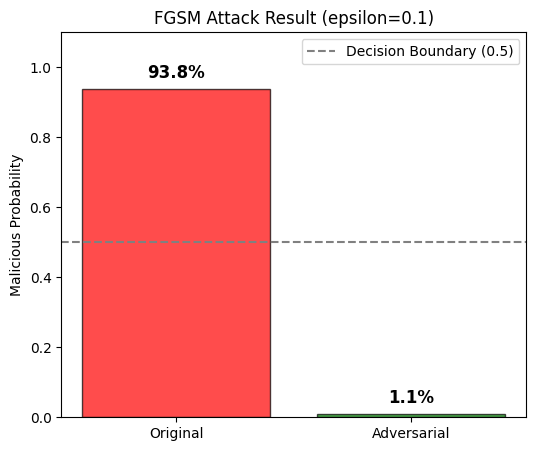


✅ 攻擊成功！模型被欺騙，將惡意網址誤判為良性 (False Negative)。


In [ ]:
# @title 7. 執行攻擊與視覺化 (Attack Execution)

# 1. 挑選一個模型預測很有信心 (機率 > 0.9) 的惡意樣本 (Label=1)
target_indices = np.where((y_test == 1) & (y_pred_prob.flatten() > 0.9))[0]
if len(target_indices) > 0:
    target_idx = target_indices[0] # 選第一個
else:
    target_idx = np.where(y_test == 1)[0][0] # 若無高信心樣本，隨選一個

input_seq = X_test[target_idx:target_idx+1]
input_label = y_test[target_idx:target_idx+1].reshape(1,1)

# 2. 計算梯度方向
original_emb, signed_grad = create_adversarial_pattern(input_seq, input_label)

# 3. 設定擾動強度 (Epsilon) - 試著調整這裡！(0.1, 0.2, 0.5)
epsilon = 0.1

# 4. 產生對抗樣本 (原始特徵 + 擾動)
adv_emb = original_emb + epsilon * signed_grad

# 5. 比較預測結果
orig_prob = classifier_model(original_emb).numpy()[0][0]
adv_prob = classifier_model(adv_emb).numpy()[0][0]

print(f"--- 攻擊參數 Epsilon: {epsilon} ---")
print(f"原始樣本預測 (惡意機率): {orig_prob:.4f}")
print(f"對抗樣本預測 (惡意機率): {adv_prob:.4f}")

# 6. 視覺化結果
labels = ['Original', 'Adversarial']
probs = [orig_prob, adv_prob]
colors = ['red' if p > 0.5 else 'green' for p in probs] # 紅色危險，綠色安全

plt.figure(figsize=(6, 5))
bars = plt.bar(labels, probs, color=colors, alpha=0.7, edgecolor='black')
plt.axhline(y=0.5, color='gray', linestyle='--', label='Decision Boundary (0.5)')
plt.ylabel('Malicious Probability')
plt.title(f'FGSM Attack Result (epsilon={epsilon})')
plt.ylim(0, 1.1)

# 在 Bar 上標示數值
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height:.1%}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.legend()
plt.show()

# 結論判定
if adv_prob < 0.5:
    print("\n✅ 攻擊成功！模型被欺騙，將惡意網址誤判為良性 (False Negative)。")
else:
    print("\n❌ 攻擊失敗，模型仍認為是惡意網址。請嘗試增大 Epsilon。")